In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

price_data_1 = pd.read_csv('data/TUTORIAL_ROUND_1/prices_round_0_day_-2.csv', header=0, sep=';')
price_data_2 = pd.read_csv('data/TUTORIAL_ROUND_1/prices_round_0_day_-1.csv', header=0, sep=';')
# add 1 day to price data 2
price_data_2['timestamp'] += 1000000

price_data = pd.concat([price_data_1, price_data_2])
print(price_data.head())

# calculate volume weighted mid price


   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
0   -2          0  EMERALDS         9992            11         9990   
1   -2          0  TOMATOES         4993             7         4992   
2   -2        100  TOMATOES         4998             5         4993   
3   -2        100  EMERALDS         9992            15         9990   
4   -2        200  TOMATOES         4994             6         4993   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0            25          NaN           NaN        10008            11   
1            17          NaN           NaN         5007             7   
2             7       4992.0          16.0         5007             7   
3            20          NaN           NaN        10008            15   
4            20          NaN           NaN         5008             6   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
0        10010            25          NaN           NaN    10000

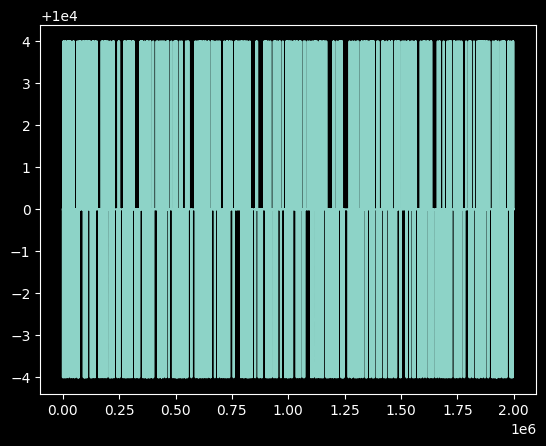

In [2]:
emerald_data = price_data[price_data['product'] == 'EMERALDS']
emerald_prices = emerald_data['mid_price']
diffed = emerald_prices.diff(1)
plt.plot(emerald_data['timestamp'], emerald_prices)

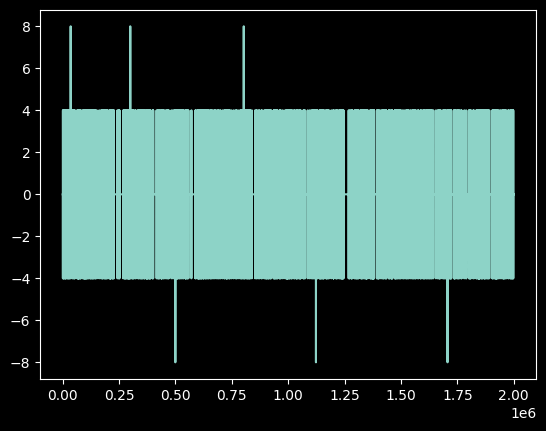

In [3]:
plt.plot(emerald_data['timestamp'], diffed)

0.9976939941163597
0.9973263198403253
0.997001801602231
0.9966617214420448
-0.42027453498390505
-0.009443962278436299
0.003439189607450148
-0.0002111273093119522


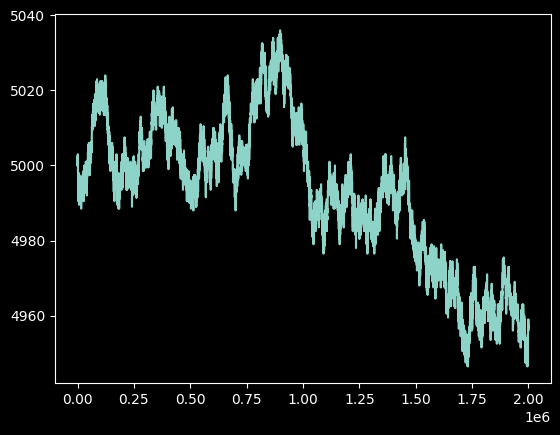

In [4]:
tomato_data = price_data[price_data['product'] == 'TOMATOES']
tomato_prices = tomato_data['mid_price']
print(tomato_prices.autocorr(lag=1))   # should be ~1.0 for random walk
print(tomato_prices.autocorr(lag=2))   # also ~0 for pure random walk
print(tomato_prices.autocorr(lag=3))
print(tomato_prices.autocorr(lag=4))
diffed = tomato_prices.diff(1)

print(diffed.autocorr())
print(diffed.autocorr(lag=2))
print(diffed.autocorr(lag=3))
print(diffed.autocorr(lag=4))

plt.plot(tomato_data['timestamp'], tomato_prices)

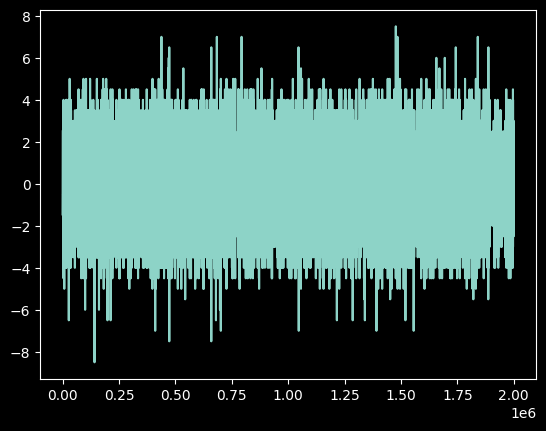

In [5]:
plt.plot(tomato_data['timestamp'], diffed)

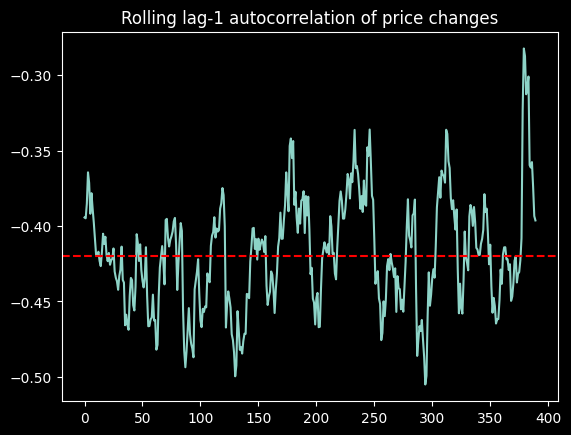

In [6]:
window = 500  # adjust based on how many timestamps you have
step = 50
rolling_autocorr = [
    diffed[i:i+window].autocorr(lag=1)
    for i in range(0, len(diffed)-window, step)  # 50% overlapping windows
]

plt.plot(rolling_autocorr)
plt.axhline(-0.42, color='red', linestyle='--', label='full sample mean')
plt.title('Rolling lag-1 autocorrelation of price changes')
plt.show()

In [7]:
from backtest_logic import Backtester
# run the backtester
bt = Backtester()
bt.run()

2-day PnL on EMERALDS: 14511.0
2-day PnL on TOMATOES: 13801.0


Text(0, 0.5, 'profit')

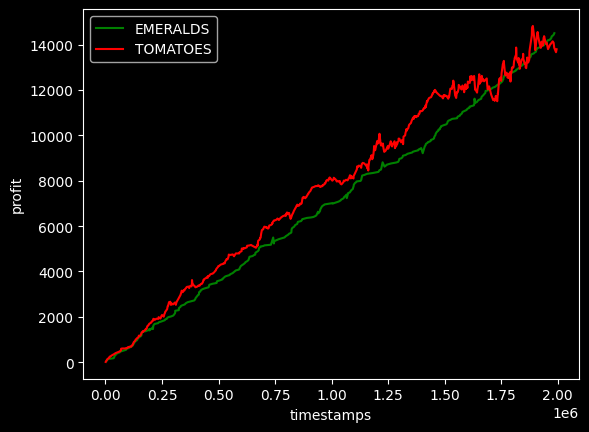

In [8]:

profit_loss = {"EMERALDS": [], "TOMATOES": []}
trade_timestamps = {"EMERALDS": [], "TOMATOES": []}
for product in bt.trade_log:
    position = 0
    cash = 0
    for trade in bt.trade_log[product]:
        if trade.buyer == "SUBMISSION":
            position += trade.quantity
            cash -= trade.quantity * trade.price
        else:
            position -= trade.quantity
            cash += trade.quantity * trade.price
        mid_price = bt.order_data[bt.order_data['product'] == product]
        mid_price = mid_price[mid_price['timestamp'] == int(trade.timestamp)]['mid_price']
        profit_loss[product].append(cash + position * float(mid_price.values[0]))
        trade_timestamps[product].append(int(trade.timestamp))
    print(f'2-day PnL on {product}: {profit_loss[product][-1]}')

plt.plot(trade_timestamps["EMERALDS"], profit_loss['EMERALDS'], label='EMERALDS', color='green')
plt.plot(trade_timestamps["TOMATOES"], profit_loss['TOMATOES'], label='TOMATOES', color='red')
plt.legend()
plt.xlabel('timestamps')
plt.ylabel('profit')



6.399521531100478
-6.529255319148936
6.46095717884131
[np.float64(6.5), np.float64(6.5), np.float64(4.0), np.float64(7.0), np.float64(6.5), np.float64(4.5), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(7.0), np.float64(7.0), np.float64(6.5), np.float64(7.0), np.float64(6.5), np.float64(7.0), np.float64(4.0), np.float64(7.0), np.float64(6.5), np.float64(2.5), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(7.0), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(7.0), np.float64(7.0), np.float64(3.5), np.float64(6.5), np.float64(7.0), np.float64(7.0), np.float64(6.5), np.float64(7.0), np.float64(6.5), np.float64(6.5), np.float64(7.0), np.float64(7.0), np.float64(6.5), np.float64(7.0), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(7.0), np.float64(7.0), np.float64(7.0), np.float64(6.5), np.float64(6.5), np.float64(6.5), np.float64(4.0), np.float64(6.5), np.float64(7.0), np.float64(6.5), np.float64

(array([ 2.,  7.,  6.,  6.,  2.,  0.,  0.,  0., 89., 97.]),
 array([2.5 , 2.95, 3.4 , 3.85, 4.3 , 4.75, 5.2 , 5.65, 6.1 , 6.55, 7.  ]),
 <BarContainer object of 10 artists>)

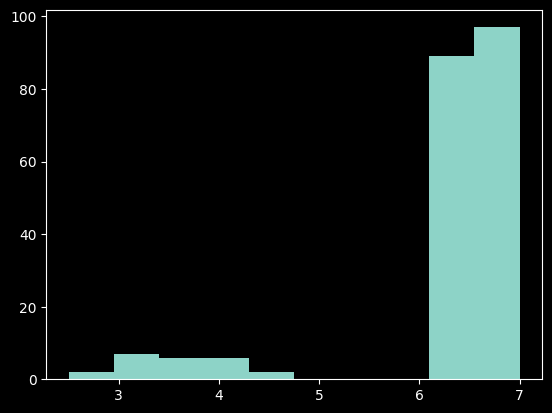

In [9]:
trades_data = pd.read_csv('data/TUTORIAL_ROUND_1/trades_round_0_day_-2.csv', header=0, sep=';')
tomato_trades = trades_data[trades_data['symbol'] == 'TOMATOES']
timestamps = list(tomato_trades['timestamp'])

tot = 0
tot_2 = 0
count_1 = 0
diffs_1 = []
diffs_2 = []
for timestamp in timestamps:
    tomatoes = price_data[price_data['product'] == 'TOMATOES']
    tomato_price = tomatoes[tomatoes['timestamp'] == timestamp]['mid_price'].to_numpy()[0]
    dif = tomato_price - tomato_trades[tomato_trades['timestamp'] == timestamp]['price'].to_numpy()[0]
    if dif >= 0:
        tot += dif
        count_1 += 1
        diffs_1.append(abs(dif))
    else:
        tot_2 += dif
        diffs_2.append(abs(dif))
print(tot/count_1)
print(tot_2/(len(timestamps)-count_1))
print((tot+abs(tot_2))/(len(timestamps)))
print(diffs_1)
print(diffs_2)
plt.hist(diffs_1)
